[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZeruiW/frontier-ai-courses/blob/main/C00_VLM_Multimodal_Course/02_contrastive_clip/02_clip_siglip.ipynb)

# 02 · 对比对齐：CLIP / SigLIP

**配套讲解**：`02_讲解.html` · **算力**：CPU 可跑（CLIP-B/32 与 SigLIP-B/16 各 ~350–400MB），有 GPU 更快

本 notebook 动手验证讲解里的核心机制：

1. 加载真实 **CLIP** (`openai/clip-vit-base-patch32`)，看双塔结构
2. **零样本分类**：给一张图一组候选标签，打印各类概率
3. **图文检索**：4 张图 × 5 条 caption，算相似度矩阵并画 heatmap
4. **手算 InfoNCE**：取归一化嵌入，`logits = logit_scale.exp() * img @ txt.T`，用 `F.cross_entropy` 算对称损失，验证理解
5. **SigLIP** (`google/siglip-base-patch16-224`)：零样本，强调 **sigmoid → 每类独立概率、不做跨类 softmax**
6. **模态鸿沟可视化**：embed N 图 + N 文，PCA 到 2D，看两个分离的簇
7. **3 道 ✏️ 练习**：纯 numpy 手写 InfoNCE、SigLIP sigmoid loss、zero-shot 分类与 temperature（CPU 可跑，不需下载模型）

> 核心 takeaway：**对齐 = 把图文压进同一空间里彼此可比较排序；但两模态仍各自聚团（modality gap）。**

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
import transformers

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"使用设备 device = {device}")
print(f"torch        = {torch.__version__}")
print(f"transformers = {transformers.__version__}")

使用设备 device = cuda
torch        = 2.11.0+cu128
transformers = 5.13.1


## 1. 加载 CLIP（双塔）并看结构

`openai/clip-vit-base-patch32`：图像塔是 ViT-B/32，文本塔是 GPT 式 Transformer，联合嵌入维度 `d=512`。

`CLIPModel` 把两塔 + 两个投影 + 可学习温度 `logit_scale` 都打包好了。
`CLIPProcessor` 同时负责图像预处理和文本 tokenize。

In [2]:
from transformers import CLIPModel, CLIPProcessor

clip_ckpt = "openai/clip-vit-base-patch32"
clip = CLIPModel.from_pretrained(clip_ckpt).to(device).eval()
clip_proc = CLIPProcessor.from_pretrained(clip_ckpt)

# logit_scale 就是讲解第 4 节的可学习温度 exp(t)
ls = clip.logit_scale.exp().item()
print(f"联合嵌入维度 projection_dim = {clip.config.projection_dim}")
print(f"logit_scale = exp(t) = {ls:.2f}   ->  等价温度 tau = 1/exp(t) = {1.0/ls:.4f}")
print("（论文初始 tau=0.07，训练后通常落在 0.01 附近，被 clamp 上限 exp(t)<=100）")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

联合嵌入维度 projection_dim = 512
logit_scale = exp(t) = 100.00   ->  等价温度 tau = 1/exp(t) = 0.0100
（论文初始 tau=0.07，训练后通常落在 0.01 附近，被 clamp 上限 exp(t)<=100）


## 2. 准备一张样例图：COCO 经典"两只猫"

与模块 01 同一张图（HuggingFace 文档同款）。若无网络，可换成本地任意图片。

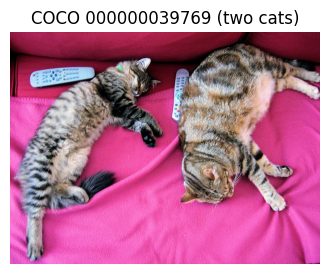

图像尺寸: (640, 480)


In [3]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
plt.figure(figsize=(4, 4)); plt.imshow(image); plt.axis("off")
plt.title("COCO 000000039769 (two cats)"); plt.show()
print("图像尺寸:", image.size)

## 3. 零样本分类：候选标签 → 各类概率

套讲解第 5 节的模板 `"a photo of a {class}"`，把每个类别变成一句话编码成文本向量，
再看图像向量和谁最近。`CLIPModel` 直接给出 `logits_per_image`（= `exp(t)·img·txtᵀ`），对它做 softmax 即各类概率。

In [11]:
labels = ["cats", "dog", "two cats", "a remote control", "a car", "a sofa"]
prompts = [f"a photo of a {c}" for c in labels]

inputs = clip_proc(text=prompts, images=image, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    out = clip(**inputs)

# logits_per_image: [1, num_labels] = exp(t) * (img_embed · txt_embedᵀ)
probs = out.logits_per_image.softmax(dim=-1)[0].cpu().numpy()

print("零样本分类（prompt = 'a photo of a {class}'）：")
for c, p in sorted(zip(labels, probs), key=lambda kv: -kv[1]):
    print(f"  {c:18s}  {p:6.2%}   {'#' * int(p * 40)}")
print(f"\n预测 = {labels[int(probs.argmax())]}  (注意 'two cats' / 'cat' 都高 -> 计数弱点，见讲解第 8 节)")

零样本分类（prompt = 'a photo of a {class}'）：
  two cats            70.65%   ############################
  cats                26.64%   ##########
  a remote control     2.13%   
  a sofa               0.55%   
  dog                  0.01%   
  a car                0.00%   

预测 = two cats  (注意 'two cats' / 'cat' 都高 -> 计数弱点，见讲解第 8 节)


## 4. 图文检索：相似度矩阵 + heatmap

4 张图 × 5 条 caption，算出 `4×5` 的余弦相似度矩阵。
对角附近应最亮（正确配对）。这就是讲解第 4 节那张相似度矩阵的真实版本（非方阵，因为图≠文数量）。

/tmp/ipykernel_3651/98701250.py:33: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.title("CLIP 图文相似度矩阵 (越亮越匹配)"); plt.tight_layout(); plt.show()
/tmp/ipykernel_3651/98701250.py:33: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.title("CLIP 图文相似度矩阵 (越亮越匹配)"); plt.tight_layout(); plt.show()
/tmp/ipykernel_3651/98701250.py:33: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.title("CLIP 图文相似度矩阵 (越亮越匹配)"); plt.tight_layout(); plt.show()
/tmp/ipykernel_3651/98701250.py:33: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from font(s) DejaVu Sans.
  plt.title("CLIP 图文相似度矩阵 (越亮越匹配)"); plt.tight_layout(); plt.show()
/tmp/ipykernel_3651/98701250.py:33: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.title("CLIP 图文相似度矩阵 (越亮越匹配)"); plt.tight_layout(); plt.show()
/tmp/ipykernel_3651/

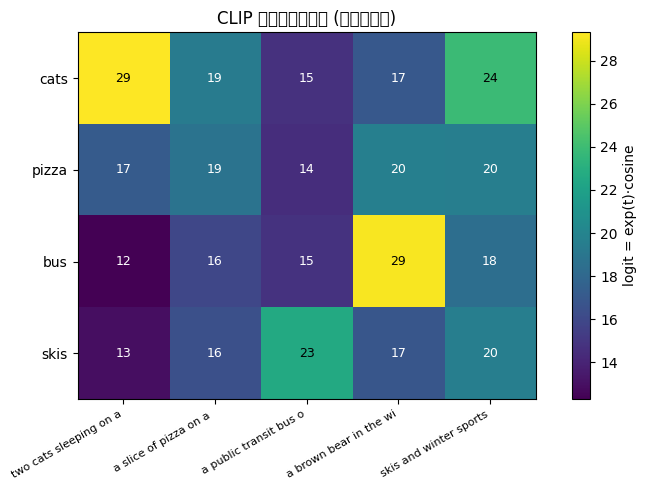

注意：第 4 张图(skis) 没有完全对应的 caption，且有个干扰项 'brown bear' 无对应图 -> 检索的真实场景。


In [5]:
img_urls = {
    "cats":   "http://images.cocodataset.org/val2017/000000039769.jpg",
    "pizza":  "http://images.cocodataset.org/val2017/000000000139.jpg",
    "bus":    "http://images.cocodataset.org/val2017/000000000285.jpg",
    "skis":   "http://images.cocodataset.org/val2017/000000000724.jpg",
}
images = [Image.open(requests.get(u, stream=True).raw).convert("RGB") for u in img_urls.values()]
img_names = list(img_urls.keys())

captions = [
    "two cats sleeping on a couch",
    "a slice of pizza on a table",
    "a public transit bus on the street",
    "a brown bear in the wild",
    "skis and winter sports gear",
]

inputs = clip_proc(text=captions, images=images, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    out = clip(**inputs)
sim = out.logits_per_image.cpu().numpy()   # [n_img, n_txt]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(sim, cmap="viridis")
ax.set_xticks(range(len(captions)))
ax.set_xticklabels([c[:22] for c in captions], rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(img_names))); ax.set_yticklabels(img_names)
for i in range(sim.shape[0]):
    for j in range(sim.shape[1]):
        ax.text(j, i, f"{sim[i, j]:.0f}", ha="center", va="center",
                color="white" if sim[i, j] < sim.max() * 0.7 else "black", fontsize=9)
plt.colorbar(im, label="logit = exp(t)·cosine")
plt.title("CLIP 图文相似度矩阵 (越亮越匹配)"); plt.tight_layout(); plt.show()
print("注意：第 4 张图(skis) 没有完全对应的 caption，且有个干扰项 'brown bear' 无对应图 -> 检索的真实场景。")

## 5. 手算 InfoNCE：逐项验证讲解第 4 节

直接从两塔取**归一化后的联合嵌入**，亲手复现对称损失：

1. `img_emb`, `txt_emb` 已 L2 归一化（`get_image_features` 后手动归一化）
2. `logits = logit_scale.exp() * img_emb @ txt_emb.T`  —— 即 `exp(t)·(I·Tᵀ)`
3. 用 4 张图配 4 条**正确对应**的 caption，正确配对在对角线 -> `labels = arange(B)`
4. 行方向 `F.cross_entropy(logits, labels)` = image→text；列方向用 `logits.T` = text→image
5. 对称损失 = 两者平均

我们手算的结果应与 `CLIPModel` 内部 loss 完全一致。

In [6]:
# 取 4 张图与各自正确的 caption（对角配对）
paired_caps = [
    "two cats sleeping on a couch",
    "a slice of pizza on a table",
    "a public transit bus on the street",
    "skis and winter sports gear",
]
inputs = clip_proc(text=paired_caps, images=images, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    img_emb = clip.get_image_features(pixel_values=inputs["pixel_values"])
    txt_emb = clip.get_text_features(input_ids=inputs["input_ids"],
                                     attention_mask=inputs["attention_mask"])

# transformers v5 起 get_*_features 返回 BaseModelOutputWithPooling，投影嵌入在 .pooler_output；
# v4 直接返回张量。getattr 兼容两种版本。
img_emb = getattr(img_emb, "pooler_output", img_emb)
txt_emb = getattr(txt_emb, "pooler_output", txt_emb)

# L2 归一化 -> 单位球面，点积 = 余弦相似度
img_emb = F.normalize(img_emb, dim=-1)
txt_emb = F.normalize(txt_emb, dim=-1)

logit_scale = clip.logit_scale.exp()
logits = logit_scale * img_emb @ txt_emb.t()    # [B, B] = exp(t)·(I·Tᵀ)
B = logits.size(0)
labels = torch.arange(B, device=device)         # 对角线下标 = 正样本

loss_i2t = F.cross_entropy(logits, labels)       # 行方向：image -> text
loss_t2i = F.cross_entropy(logits.t(), labels)   # 列方向：text -> image
loss_sym = 0.5 * (loss_i2t + loss_t2i)

print("logits (exp(t)·cosine):")
print(np.round(logits.detach().cpu().numpy(), 1))
print(f"\nL_i2t (image->text) = {loss_i2t.item():.4f}")
print(f"L_t2i (text->image) = {loss_t2i.item():.4f}")
print(f"对称 InfoNCE 损失    = {loss_sym.item():.4f}")
print("\n对角线应是每行/每列最大值 -> 说明配对图文相似度最高（对齐成功）。")

logits (exp(t)·cosine):
[[29.3 19.3 14.7 23.9]
 [17.2 18.8 14.5 19.6]
 [12.3 15.9 14.8 18.5]
 [12.9 16.4 22.6 19.6]]

L_i2t (image->text) = 2.0358
L_t2i (text->image) = 3.3195
对称 InfoNCE 损失    = 2.6777

对角线应是每行/每列最大值 -> 说明配对图文相似度最高（对齐成功）。


## 6. SigLIP：sigmoid → 每类独立概率，不做跨类 softmax

`google/siglip-base-patch16-224` 用 `AutoModel` / `AutoProcessor` 加载。关键区别（讲解第 6 节）：

- SigLIP 用 **sigmoid pairwise loss**，每个图文对是独立二分类
- 推理时对 `logits_per_image` 取 **`torch.sigmoid`**，得到**每个类各自独立的概率**
- **不做跨类 softmax** —— 所以各类概率**不必加和为 1**（可以都低、也可以多个都高）

> SigLIP processor 需要 `padding="max_length"`（其文本塔按固定长度 64 训练）。

In [7]:
from transformers import AutoModel, AutoProcessor

sig_ckpt = "google/siglip-base-patch16-224"
sig = AutoModel.from_pretrained(sig_ckpt).to(device).eval()
sig_proc = AutoProcessor.from_pretrained(sig_ckpt)

# SigLIP 官方推荐的 prompt 模板，注意 padding="max_length"
sig_labels = ["2 cats", "a dog", "a remote control", "a pizza"]
sig_prompts = [f"This is a photo of {c}." for c in sig_labels]

inputs = sig_proc(text=sig_prompts, images=image, return_tensors="pt",
                  padding="max_length").to(device)
with torch.no_grad():
    out = sig(**inputs)

# 关键：sigmoid，而不是 softmax -> 每类独立概率
probs_sigmoid = torch.sigmoid(out.logits_per_image)[0].cpu().numpy()

print("SigLIP 零样本（sigmoid，每类独立概率，不跨类归一化）：")
for c, p in zip(sig_labels, probs_sigmoid):
    print(f"  {c:18s}  P(match)={p:6.2%}   {'#' * int(p * 40)}")
print(f"\n各类概率之和 = {probs_sigmoid.sum():.3f}  <- 不为 1！这正是 sigmoid 与 softmax 的本质区别。")

config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


model.safetensors: reconstructing file:   0%|          |  0.00B /  813MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

...

spiece.model: reconstructing file:   0%|          |  0.00B /  798kB            

spiece.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

SigLIP 零样本（sigmoid，每类独立概率，不跨类归一化）：
  2 cats              P(match)=19.83%   #######
  a dog               P(match)= 0.00%   
  a remote control    P(match)= 0.00%   
  a pizza             P(match)= 0.00%   

各类概率之和 = 0.198  <- 不为 1！这正是 sigmoid 与 softmax 的本质区别。


## 7. 模态鸿沟可视化：图簇 vs 文簇

embed N 张图 + N 条文，全部 L2 归一化后一起 PCA 到 2D。
按讲解第 7 节，应看到**两个分离的簇**——即使配对图文余弦不低，两模态整体各占一片（modality gap [Liang 2022]）。

/tmp/ipykernel_3651/2118348998.py:24: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()
/tmp/ipykernel_3651/2118348998.py:24: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()
/tmp/ipykernel_3651/2118348998.py:24: UserWarning: Glyph 23884 (\N{CJK UNIFIED IDEOGRAPH-5D4C}) missing from font(s) DejaVu Sans.
  plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()
/tmp/ipykernel_3651/2118348998.py:24: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()
/tmp/ipykernel_3651/2118348998.py:24: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()
/tmp/i

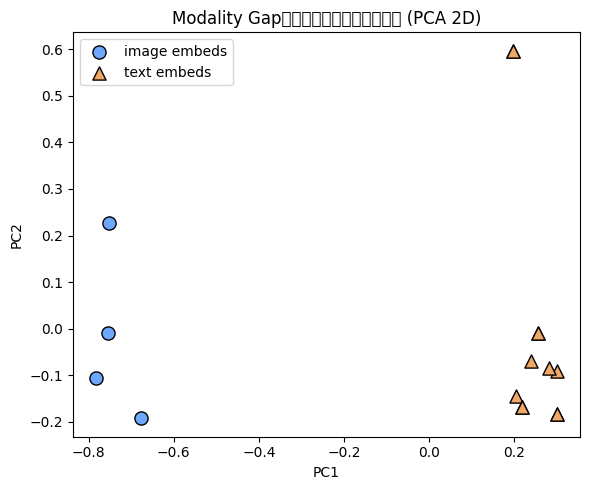

图-图平均余弦 = 0.649
文-文平均余弦 = 0.693
图-文平均余弦 = 0.182   <- 明显更低：跨模态被一条间隙隔开 = modality gap


In [8]:
# 用一批多样的图与文（这里复用上面的图，并加更多文本扩充样本）
gap_imgs = images   # 4 张
gap_caps = captions + paired_caps + ["a dog playing", "a city at night", "a cup of coffee"]

with torch.no_grad():
    im_in = clip_proc(images=gap_imgs, return_tensors="pt").to(device)
    img_out = clip.get_image_features(pixel_values=im_in["pixel_values"])
    ie = F.normalize(getattr(img_out, "pooler_output", img_out), dim=-1)  # v5: 投影嵌入在 .pooler_output
    tx_in = clip_proc(text=gap_caps, return_tensors="pt", padding=True).to(device)
    txt_out = clip.get_text_features(input_ids=tx_in["input_ids"],
                                     attention_mask=tx_in["attention_mask"])
    te = F.normalize(getattr(txt_out, "pooler_output", txt_out), dim=-1)

allv = torch.cat([ie, te], dim=0).cpu().numpy()
allv = allv - allv.mean(0, keepdims=True)            # 中心化
U, S, Vt = np.linalg.svd(allv, full_matrices=False)  # PCA via SVD
proj = allv @ Vt[:2].T                                 # -> 2D
n_img = ie.shape[0]

plt.figure(figsize=(6, 5))
plt.scatter(proj[:n_img, 0], proj[:n_img, 1], c="#6ea8fe", s=90, label="image embeds", edgecolor="k")
plt.scatter(proj[n_img:, 0], proj[n_img:, 1], c="#f0a868", s=90, label="text embeds", marker="^", edgecolor="k")
plt.legend(); plt.title("Modality Gap：图嵌入与文嵌入各自聚团 (PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

# 量化：同模态平均相似度 vs 跨模态平均相似度
img_img = (ie @ ie.t()).mean().item()
txt_txt = (te @ te.t()).mean().item()
img_txt = (ie @ te.t()).mean().item()
print(f"图-图平均余弦 = {img_img:.3f}")
print(f"文-文平均余弦 = {txt_txt:.3f}")
print(f"图-文平均余弦 = {img_txt:.3f}   <- 明显更低：跨模态被一条间隙隔开 = modality gap")

---
## ✏️ 练习 1：手写 CLIP 对称 InfoNCE loss（numpy 版）

第 5 节用 `F.cross_entropy` 验证了 CLIP 的对称损失，这里脱离 torch、用纯 numpy 再实现一遍：`clip_infonce_loss(img_emb, txt_emb, scale)`，输入 B×d 的图/文嵌入（**不保证已归一化**）与 `scale`（= `logit_scale.exp()`，即 `exp(t)`），返回标量 loss：

1. 两组嵌入各自 **L2 归一化**（沿 `axis=-1`）；
2. `logits = scale * img @ txt.T`（B×B，对角线 = 正确配对）；
3. image→text：对每**行**做 softmax，取对角元素的 `-log`，求平均；
4. text→image：对 `logits.T` 重复第 3 步；
5. 返回两者的平均。

**提示**：softmax 前先减每行 max 防溢出；`-log softmax(row)[i]` 可直接写成 `logsumexp(row) - row[i]`，避免先 exp 再 log。约 12 行。边界：`scale=0` 时所有 logits 为 0 → 行内均匀分布 → loss 应**精确**等于 `ln(B)`。

In [9]:
import numpy as np   # 练习区全程只用 numpy，不依赖前面需联网/torch 的 cell

def clip_infonce_loss(img_emb, txt_emb, scale):
    # TODO:
    #   1) L2 归一化 img_emb / txt_emb（axis=-1, keepdims=True）
    #   2) logits = scale * img @ txt.T
    #   3) image->text：每行 softmax 交叉熵，目标 = 对角线，取均值
    #   4) text->image：对 logits.T 重复第 3 步
    #   5) 返回 (loss_i2t + loss_t2i) / 2
    raise NotImplementedError

In [10]:
# —— 练习 1 自测 ——
B, d = 3, 6
eye = np.eye(B, d)                                   # 3 对互相正交的“完美对齐”嵌入

assert clip_infonce_loss(eye, eye, 100.0) < 1e-6     # 完美对齐 + 大 scale -> loss ~ 0
assert abs(clip_infonce_loss(eye, eye, 0.0) - np.log(B)) < 1e-9   # scale=0 -> 均匀 -> ln(B)

rng = np.random.default_rng(0)
img = rng.normal(size=(4, 8)); txt = img + 0.1 * rng.normal(size=(4, 8))
l_good = clip_infonce_loss(img, txt, 50.0)
l_bad  = clip_infonce_loss(img, txt[::-1], 50.0)     # 打乱配对 -> 对角线不再是正样本
assert l_good < l_bad                                # 正确配对的 loss 必须更低
assert abs(clip_infonce_loss(img, txt, 50.0) - clip_infonce_loss(txt, img, 50.0)) < 1e-9  # 对称损失：换边不变
assert abs(clip_infonce_loss(7.0 * img, txt, 50.0) - l_good) < 1e-9   # 函数内部归一化 -> 输入缩放不变
print("✅ 练习 1 通过")

NotImplementedError: 

## ✏️ 练习 2：实现 SigLIP 的 pairwise sigmoid loss

复现第 6 节的关键区别：`siglip_pairwise_loss(img_emb, txt_emb, t, b)`，把 B×B 里每个图文对当作**独立二分类**（[Zhai 2023]）：

1. L2 归一化后 `z = t * img @ txt.T + b`（`t` 是温度，`b` 是可学习 bias）；
2. 标签矩阵 `labels = 2·I − 1`：对角 +1（正样本），其余 −1（负样本）；
3. 每对的损失 = `-log σ(labels * z)`，对全部 B×B 个 pair 取**平均**（论文按 batch size B 归一，这里取 B² 均值只差常数因子，不影响理解）。

**提示**：数值稳定的 `-log σ(x)` 就是 `np.logaddexp(0, -x)`，别写 `np.log(1/(1+np.exp(-x)))`（大 `|x|` 会溢出）。约 7 行。顺便体会论文为什么把 `b` 初始化成 −10：B×B 里绝大多数是负样本，若 `b=0`，正交负样本对 z=0、σ(0)=0.5，开局每个负对就贡献 log2 的损失。

In [ ]:
def siglip_pairwise_loss(img_emb, txt_emb, t, b):
    # TODO:
    #   1) L2 归一化两组嵌入
    #   2) z = t * img @ txt.T + b
    #   3) labels = 2 * I - 1（对角 +1，其余 -1）
    #   4) 返回 np.logaddexp(0, -labels * z) 的均值（= -log sigmoid 的数值稳定版）
    raise NotImplementedError

In [ ]:
# —— 练习 2 自测 ——
eye2 = np.eye(2)
# 手算对照：t=1, b=0 时 z = I，labels*z 对角 = 1、非对角 = 0
expected = (2 * np.logaddexp(0, -1.0) + 2 * np.logaddexp(0, 0.0)) / 4
assert abs(siglip_pairwise_loss(eye2, eye2, 1.0, 0.0) - expected) < 1e-9

eye4 = np.eye(4, 8)
assert siglip_pairwise_loss(eye4, eye4, 100.0, 0.0) > 0.4      # b=0：12 个正交负对各贡献 log2，loss 下不去
assert siglip_pairwise_loss(eye4, eye4, 20.0, -10.0) < 1e-3    # 负 bias 把正负样本都推进饱和区 -> loss ~ 0
assert np.isfinite(siglip_pairwise_loss(eye4, eye4, 1e4, -10.0))   # 数值稳定：超大温度不产生 inf/nan

rng = np.random.default_rng(1)
img = rng.normal(size=(4, 8)); txt = img + 0.1 * rng.normal(size=(4, 8))
assert siglip_pairwise_loss(img, txt, 20.0, -10.0) < siglip_pairwise_loss(img, txt[::-1], 20.0, -10.0)
print("✅ 练习 2 通过")

## ✏️ 练习 3：zero-shot 分类 + temperature 的作用

把第 3 节的零样本分类抽象成纯 numpy 函数：`zero_shot_probs(img_emb, cls_emb, scale)`，输入 N×d 图像嵌入和 C×d 类别文本嵌入（不保证归一化），返回 N×C 概率矩阵：

1. 两边 L2 归一化 → `logits = scale * img @ cls.T`（N×C 余弦相似度 × 温度）；
2. 对每**行**做 softmax → 概率；预测类别 = 每行 argmax。

重点体会 `scale`（= `exp(t)`）的作用：余弦相似度天然挤在 [−1, 1]，不放大时 softmax 接近均匀；`scale` 越大分布越尖。

**提示**：softmax 同练习 1（减行 max 防溢出）；约 6 行。边界：`scale=0` → 每行严格均匀（每个概率 = 1/C）；softmax 单调、不改排序，所以 argmax 必须与“按余弦找最近类别原型”一致。

In [ ]:
def zero_shot_probs(img_emb, cls_emb, scale):
    # TODO:
    #   1) L2 归一化 img_emb / cls_emb
    #   2) logits = scale * img @ cls.T
    #   3) 每行 softmax（先减行 max 防溢出），返回 N×C 概率矩阵
    raise NotImplementedError

In [ ]:
# —— 练习 3 自测 ——
rng = np.random.default_rng(2)
cls = np.eye(3, 8)                                          # 3 个正交“类别原型”
img = cls[[0, 2, 1, 0]] + 0.05 * rng.normal(size=(4, 8))    # 4 张图，真实类别 [0, 2, 1, 0]

probs = zero_shot_probs(img, cls, 30.0)
assert probs.shape == (4, 3)
assert np.allclose(probs.sum(axis=1), 1.0)                  # 每行概率和为 1
assert list(probs.argmax(axis=1)) == [0, 2, 1, 0]           # 预测 = 余弦最近的类别原型
assert np.allclose(zero_shot_probs(img, cls, 0.0), 1.0 / 3) # scale=0 -> 严格均匀
p_sharp = zero_shot_probs(img, cls, 100.0).max(axis=1)
p_flat  = zero_shot_probs(img, cls, 1.0).max(axis=1)
assert np.all(p_sharp > p_flat)                             # temperature：scale 越大分布越尖
assert np.allclose(zero_shot_probs(5.0 * img, cls, 30.0), probs)   # 内部归一化 -> 输入缩放不变
print("✅ 练习 3 通过")

---
## 📖 参考答案

In [ ]:
# 练习 1 参考答案（先自己做，再对照）
def clip_infonce_loss(img_emb, txt_emb, scale):
    img = img_emb / np.linalg.norm(img_emb, axis=-1, keepdims=True)
    txt = txt_emb / np.linalg.norm(txt_emb, axis=-1, keepdims=True)
    logits = scale * img @ txt.T

    def ce_diag(z):                                   # 每行 softmax 交叉熵，目标 = 对角线
        z = z - z.max(axis=-1, keepdims=True)         # 防溢出
        logsumexp = np.log(np.exp(z).sum(axis=-1))
        return np.mean(logsumexp - np.diag(z))        # -log softmax(z)[i,i] 的均值

    return (ce_diag(logits) + ce_diag(logits.T)) / 2

In [ ]:
# 练习 2 参考答案（先自己做，再对照）
def siglip_pairwise_loss(img_emb, txt_emb, t, b):
    img = img_emb / np.linalg.norm(img_emb, axis=-1, keepdims=True)
    txt = txt_emb / np.linalg.norm(txt_emb, axis=-1, keepdims=True)
    z = t * img @ txt.T + b
    labels = 2 * np.eye(z.shape[0]) - 1               # 对角 +1，其余 -1
    return np.mean(np.logaddexp(0.0, -labels * z))    # -log sigmoid(labels*z) 的稳定写法

In [ ]:
# 练习 3 参考答案（先自己做，再对照）
def zero_shot_probs(img_emb, cls_emb, scale):
    img = img_emb / np.linalg.norm(img_emb, axis=-1, keepdims=True)
    cls = cls_emb / np.linalg.norm(cls_emb, axis=-1, keepdims=True)
    logits = scale * img @ cls.T
    logits = logits - logits.max(axis=-1, keepdims=True)
    e = np.exp(logits)
    return e / e.sum(axis=-1, keepdims=True)

## 8. 小结与练习

**你刚刚验证了：**
- CLIP 双塔：图/文各自编码 → 投影到 `d=512` 联合空间 → L2 归一化 → `exp(t)·cosine`
- 零样本分类 = 把类别写成句子、比谁最近；prompt 模板影响明显
- 图文检索 = 一个相似度矩阵，对角线最亮
- **手算 InfoNCE** 与 `CLIPModel` 内部一致：对称交叉熵 + 可学习温度 `logit_scale`
- **SigLIP 用 sigmoid**：每类独立概率、各类不加和为 1（区别于 CLIP 的 softmax）
- **模态鸿沟真实存在**：图嵌入和文嵌入在 PCA 图上分成两团，跨模态余弦显著低于同模态

**练习（建议动手）：**
1. **Prompt ensembling**：对每个类用 5–8 个模板（`"a photo of a {c}."`、`"a blurry photo of a {c}."`…），在归一化嵌入空间里平均成"类原型"再归一化，对比第 3 节单模板的零样本准确率是否提升。
2. **换 SigLIP 做检索**：用 SigLIP 重做第 4 节的相似度矩阵（记得 `torch.sigmoid` 而非 softmax，且 `padding="max_length"`），对比谁的对角更突出。
3. **组合性探针**：构造 `"a red cube on a blue sphere"` vs `"a blue cube on a red sphere"`，对同一张图算 CLIP 相似度，观察对调颜色后相似度几乎不变 —— 亲手复现讲解第 8 节的"词袋行为"。

➡️ 下一站：**模块 03 — VLM 架构演进**，看 CLIP 这样的视觉骨干如何通过 connector 接入 LLM，组成真正的视觉-语言模型。

---
## 🎯 真实数据胶囊题：真实图像特征上的 InfoNCE 对比损失

CLIP 用对比损失：让匹配的图文对相似度最高。用真实图像 patch 特征构造一个 batch(对角为匹配对)，实现 InfoNCE，验证当匹配对相似度提高时 loss 下降。

> 本模块新增的**真实数据**练习：用**真实图像**把本章方法跑一遍。先做 TODO，`assert` 全过即通关，文末有参考答案。

In [ ]:
import os, io, urllib.request
import numpy as np
import matplotlib.image as mpimg
CACHE=os.path.expanduser("~/.vlm_data"); os.makedirs(CACHE,exist_ok=True)
def real_image():
    "真实图像 Grace Hopper (来自 matplotlib 示例数据), 返回 (H,W,3) uint8"
    p=os.path.join(CACHE,"grace_hopper.jpg")
    if not os.path.exists(p):
        urllib.request.urlretrieve("https://raw.githubusercontent.com/matplotlib/matplotlib/main/lib/matplotlib/mpl-data/sample_data/grace_hopper.jpg", p)
    return mpimg.imread(p)

img=real_image().astype(float)/255
# 用真实图像不同区域的特征当一个 batch 的"图像嵌入"
def feat(region): return region.reshape(-1)[:64]
rng=np.random.default_rng(0)
B=8; d=64
# 图像嵌入 + 对应文本嵌入(匹配对=同特征+噪声)
I=np.stack([feat(img[i*40:(i+1)*40]) for i in range(B)])
T=I + rng.normal(0,0.01,I.shape)   # 匹配文本嵌入接近图像嵌入
I/=np.linalg.norm(I,axis=1,keepdims=True); T/=np.linalg.norm(T,axis=1,keepdims=True)
print("图文 batch:", I.shape)

**练习**：实现 `infonce(I, T, temp)`：相似度矩阵 `S=I@T.T/temp`，对角是匹配对，返回对称交叉熵损失（行方向 + 列方向，标签为对角 index）。

In [ ]:
def infonce(I, T, temp=0.07):
    # TODO: S=I@T.T/temp; 行 softmax 交叉熵(标签=arange) + 列方向，取平均
    raise NotImplementedError


In [ ]:
# 自测
loss=infonce(I, T)
# 把匹配对(对角)拉得更近 -> loss 更低
T2=I.copy()   # 完美匹配
assert infonce(I, T2) < loss, "匹配对更相似时 loss 应更低"
# 随机配对 loss 高
Tr=T[rng.permutation(B)]
assert infonce(I, Tr) > infonce(I, T2)
print(f"InfoNCE ✓  噪声匹配 loss={loss:.3f}, 完美匹配更低, 随机配对更高")


### 📖 参考答案

In [ ]:
def infonce(I, T, temp=0.07):
    S=I@T.T/temp; n=len(I); y=np.arange(n)
    def ce(logits):
        z=logits-logits.max(1,keepdims=True); p=np.exp(z)/np.exp(z).sum(1,keepdims=True)
        return -np.log(p[np.arange(n),y]+1e-12).mean()
    return 0.5*(ce(S)+ce(S.T))
print("✓ InfoNCE: 对角拉近、非对角推远，是 CLIP 对齐图文的核心")